In [1]:
%cd ..
%cd ..

/home/stan/documents/TNTM_reproduce/Code
/home/stan/documents/TNTM_reproduce


In [2]:
!pip install --upgrade gensim

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import pickle
import torch

from Code.Evaluate.Metrics import score_all, get_tw_embeddings
from Code.TNTM.TNTM_bow import TNTM_bow


[nltk_data] Downloading package brown to /home/stan/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package stopwords to /home/stan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/home/stan/miniconda3/envs/tntm_reproduce/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


current device: cuda
current device: cuda


In [5]:
with open("Data/DataOctis/octis_dataset_20ng.pickle", "rb") as file:
    octis_dataset = pickle.load(file)

corpus = octis_dataset.get_corpus()


In [6]:
tw_emb = get_tw_embeddings(octis_dataset)


100%|██████████| 48018/48018 [05:17<00:00, 151.29it/s]


In [7]:
with open(
    "Data/DataOctis/cleaned_embedding_df_20ng_BERT.pickle",
    "rb",
) as f:
    embedding_df = pickle.load(f)


In [8]:
embedding_df.sort_values(by="word", inplace=True)


In [9]:
embedding_ten_lis = []

for i in range(len(embedding_df)):
    embedding_ten_lis.append(embedding_df["embedding"].iloc[i])


In [10]:
embedding_df.sort_values(by="word", inplace=True)
embedding_ten_lis = []

embedded_words = embedding_df.index.tolist()

for i in range(len(embedding_df)):
    embedding_ten_lis.append(embedding_df["embedding"].iloc[i])
embedding_ten = torch.stack(embedding_ten_lis)


In [11]:
vocab = embedded_words
vocab_set = set(vocab)
corpus = [
    [word for word in doc if word in vocab_set] for doc in octis_dataset.get_corpus()
]


In [12]:
model = TNTM_bow(
    n_topics=10,
    save_path="msc/SavedResultsmodel_v2.pth",
    n_dims=11,
    n_hidden_units=200,
    n_encoder_layers=3,
    enc_lr=1e-4,
    dec_lr=1e-3,
    n_epochs=100,
    # batch_size = 128,
    batch_size=256,
    dropout_rate_encoder=0.3,
    prior_variance=0.995,
    prior_mean=None,
    n_topwords=200,
    device="cuda",
    validation_set_size=0.2,
    early_stopping=True,
    n_epochs_early_stopping=10,
    return_embeddings=False,
    eps=1e-4,
    umap_hyperparams={"n_neighbors": 15, "min_dist": 0.0},
    return_losses=True,
)


In [13]:
res_all = model.fit(corpus=corpus, vocab=vocab, embeddings=embedding_ten)


16309it [00:05, 3076.04it/s]
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mus_init_ten = torch.tensor(mus_init).to(self.device)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:171: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_lower_init_ten = torch.tensor(L_lower_init).to(self.device)
/home/sta

Epoch nr 0: mean_train_loss = -556.4653930664062, mean_train_nl = -559.0822143554688, mean_train_kld = 2.6168529987335205, elapsed time: 10.473006010055542
Epoch nr 0: median_train_loss = -523.6808471679688, median_train_nl = -526.33642578125, median_train_kld = 2.5353822708129883, elapsed time: 10.473006010055542
Epoch nr 0: mean_val_loss = -584.6943359375, mean_val_nl = -585.473388671875, mean_val_kld = 0.7790733575820923
Epoch nr 0: median_val_loss = -551.50634765625, median_val_nl = -553.4900512695312, median_val_kld = 0.3885415196418762
gradient norm: mean: 5288.21659790665, median: 2400.8384121035588, max: 100000.00729641913


Epoch nr 1: mean_train_loss = -607.716064453125, mean_train_nl = -608.3954467773438, mean_train_kld = 0.6793962121009827, elapsed time: 7.16111421585083
Epoch nr 1: median_train_loss = -595.8138427734375, median_train_nl = -597.0574340820312, median_train_kld = 0.5888116359710693, elapsed time: 7.16111421585083
Epoch nr 1: mean_val_loss = -594.0825805664062

In [14]:
len(corpus)


16309

In [15]:
# remove all documents shorter than 10 words
corpus = [doc for doc in corpus if len(doc) >= 10]


In [16]:
octis_dataset._Dataset__corpus = corpus
octis_dataset._Dataset__vocab = vocab


In [17]:
evaluation_result = score_all(
    dataset=octis_dataset,
    tw_emb=tw_emb,
    n_words=10,
    result={"topics": res_all[0], "topic-word-matrix": res_all[1]},
)


100%|██████████| 5/5 [00:03<00:00,  1.55it/s]


In [18]:
res_all


(array([['compress', 'clipper', 'wiretap', ..., 'able', 'ability', 'a'],
        ['perfect', 'fine', 'excellent', ..., 'zuma', 'aa', 'yes'],
        ['file', 'version', 'header', ..., 'zoo', 'zuma', 'a'],
        ...,
        ['monitor', 'driver', 'screen', ..., 'aa', 'zuma', 'a'],
        ['don', 'bill', 'sun', ..., 'zoo', 'zuma', 'a'],
        ['pass', 'leave', 'quit', ..., 'zuma', 'aa', 'yale']], dtype='<U14'),
 array([[3.03738814e+11, 2.84754477e+11, 2.73475633e+11, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [5.79866496e+08, 5.36659264e+08, 3.98156896e+08, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.45606938e+09, 1.62955469e+09, 1.62771264e+09, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [2.96423552e+09, 2.78202445e+09, 2.42158234e+09, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [7.28658794e+17, 1.59908247e+17, 1.09586314e+17, ...,
         0.00000000e+00, 0.

In [19]:
def eval_model_n_topics(n_topics: int):
    model = TNTM_bow(
        n_topics=n_topics,
        save_path="msc/SavedResults/model_v2.pth",
        n_dims=11,
        n_hidden_units=200,
        n_encoder_layers=3,
        enc_lr=1e-4,
        dec_lr=1e-3,
        n_epochs=100,
        # batch_size = 128,
        batch_size=256,
        dropout_rate_encoder=0.3,
        prior_variance=0.995,
        prior_mean=None,
        n_topwords=200,
        device=None,
        validation_set_size=0.2,
        early_stopping=True,
        n_epochs_early_stopping=10,
        return_embeddings=False,
        eps=1e-4,
        umap_hyperparams={"n_neighbors": 15, "min_dist": 0.0},
        return_losses=True,
    )

    res_all = model.fit(corpus=corpus, vocab=vocab, embeddings=embedding_ten)

    evaluation_result = score_all(
        dataset=octis_dataset,
        tw_emb=tw_emb,
        n_words=10,
        result={"topics": res_all[0], "topic-word-matrix": res_all[1]},
    )

    return evaluation_result


In [20]:
# evaluate different number of topics
from tqdm import tqdm

# n_topics = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
n_topics = [10, 15, 20, 50, 100, 200]
n_iter = 3

results = {}

for m in range(n_iter):
    for n in tqdm(n_topics):
        results[n] = results.get(n, []) + [eval_model_n_topics(n)]


13459it [00:03, 3672.60it/s]?, ?it/s]
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mus_init_ten = torch.tensor(mus_init).to(self.device)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:171: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_lower_init_ten = torch.tensor(L_lower_init).to(self.device)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  log_diag_init_ten = torch.tensor(log_diag_init).to(self.device)

Epoch nr 0: mean_train_loss = -615.6007080078125, mean_train_nl = -618.3489990234375, mean_train_kld = 2.7483034133911133, elapsed time: 3.878547430038452
Epoch nr 0: median_train_loss = -631.270263671875, median_train_nl = -633.7886352539062, median_train_kld = 2.5020618438720703, elapsed time: 3.878547430038452
Epoch nr 0: mean_val_loss = -762.975341796875, mean_val_nl = -764.453857421875, mean_val_kld = 1.4784774780273438
Epoch nr 0: median_val_loss = -746.1527099609375, median_val_nl = -746.4959106445312, median_val_kld = 0.7580618262290955
gradient norm: mean: 6162.076101135986, median: 2501.888833374983, max: 99999.99567564722


Epoch nr 1: mean_train_loss = -686.6699829101562, mean_train_nl = -687.247802734375, mean_train_kld = 0.5778199434280396, elapsed time: 3.7995073795318604
Epoch nr 1: median_train_loss = -664.3557739257812, median_train_nl = -664.7814331054688, median_train_kld = 0.42564457654953003, elapsed time: 3.7995073795318604
Epoch nr 1: mean_val_loss = -788.375732


100%|██████████| 10/10 [00:00<00:00, 174.00it/s]

100%|██████████| 5/5 [00:02<00:00,  1.68it/s]
13459it [00:03, 3926.02it/s]11:40, 140.16s/it]
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mus_init_ten = torch.tensor(mus_init).to(self.device)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:171: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_lower_init_ten = torch.tensor(L_lower_init).to(self.device)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True),

Epoch nr 0: mean_train_loss = -767.9825439453125, mean_train_nl = -772.1051025390625, mean_train_kld = 4.122497081756592, elapsed time: 5.334185361862183
Epoch nr 0: median_train_loss = -773.14111328125, median_train_nl = -777.2584838867188, median_train_kld = 3.862565517425537, elapsed time: 5.334185361862183
Epoch nr 0: mean_val_loss = -806.0180053710938, mean_val_nl = -806.8497924804688, mean_val_kld = 0.8318462371826172
Epoch nr 0: median_val_loss = -802.02783203125, median_val_nl = -802.6727294921875, median_val_kld = 0.6179865598678589
gradient norm: mean: 3619.573369198175, median: 2557.6575183304462, max: 12841.20649470388


Epoch nr 1: mean_train_loss = -821.9439697265625, mean_train_nl = -822.7537231445312, mean_train_kld = 0.8098287582397461, elapsed time: 5.105030298233032
Epoch nr 1: median_train_loss = -800.885986328125, median_train_nl = -801.5406494140625, median_train_kld = 0.6732698678970337, elapsed time: 5.105030298233032
Epoch nr 1: mean_val_loss = -833.568359375, 


100%|██████████| 15/15 [00:00<00:00, 215.80it/s]

100%|██████████| 5/5 [00:03<00:00,  1.54it/s]
13459it [00:03, 3546.25it/s]09:09, 137.38s/it]
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mus_init_ten = torch.tensor(mus_init).to(self.device)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:171: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_lower_init_ten = torch.tensor(L_lower_init).to(self.device)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True),

...




100%|██████████| 50/50 [00:00<00:00, 176.51it/s]


100%|██████████| 5/5 [00:04<00:00,  1.07it/s]
13459it [00:03, 4082.78it/s]08:33, 256.95s/it]
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mus_init_ten = torch.tensor(mus_init).to(self.device)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:171: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_lower_init_ten = torch.tensor(L_lower_init).to(self.device)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(Tru

Epoch nr 0: mean_train_loss = -865.7284545898438, mean_train_nl = -906.5624389648438, mean_train_kld = 40.83387756347656, elapsed time: 15.511009931564331
Epoch nr 0: median_train_loss = -863.41357421875, median_train_nl = -897.5594482421875, median_train_kld = 33.82157897949219, elapsed time: 15.511009931564331
Epoch nr 0: mean_val_loss = -1137.3265380859375, mean_val_nl = -1142.7454833984375, mean_val_kld = 5.418904781341553
Epoch nr 0: median_val_loss = -1132.890869140625, median_val_nl = -1140.16162109375, median_val_kld = 3.5306968688964844
gradient norm: mean: 27680.669159031193, median: 18698.242502841586, max: 94481.68443530727


Epoch nr 1: mean_train_loss = -1054.314453125, mean_train_nl = -1079.51904296875, mean_train_kld = 25.20451545715332, elapsed time: 15.129546880722046
Epoch nr 1: median_train_loss = -1076.2216796875, median_train_nl = -1078.648681640625, median_train_kld = 4.008718490600586, elapsed time: 15.129546880722046
Epoch nr 1: mean_val_loss = -1179.6378173828






100%|██████████| 100/100 [00:00<00:00, 185.82it/s]





100%|██████████| 5/5 [00:07<00:00,  1.49s/it]
13459it [00:03, 4080.19it/s]11:26, 686.44s/it]
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:170: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mus_init_ten = torch.tensor(mus_init).to(self.device)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:171: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  L_lower_init_ten = torch.tensor(L_lower_init).to(self.device)
/home/stan/documents/TNTM_reproduce/Code/TNTM/TNTM_bow.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_gr

Epoch nr 0: mean_train_loss = -965.5853881835938, mean_train_nl = -1066.402099609375, mean_train_kld = 100.8167495727539, elapsed time: 34.025702238082886
Epoch nr 0: median_train_loss = -979.7216796875, median_train_nl = -1044.3128662109375, median_train_kld = 58.994178771972656, elapsed time: 34.025702238082886
Epoch nr 0: mean_val_loss = -1185.0279541015625, mean_val_nl = -1195.2806396484375, mean_val_kld = 10.252641677856445
Epoch nr 0: median_val_loss = -1229.270751953125, median_val_nl = -1234.739990234375, median_val_kld = 5.689694404602051
gradient norm: mean: 31241.53544971556, median: 18659.51165310247, max: 100000.00175091412


Epoch nr 1: mean_train_loss = -1256.003173828125, mean_train_nl = -1269.9639892578125, mean_train_kld = 13.96087646484375, elapsed time: 33.26938247680664
Epoch nr 1: median_train_loss = -1266.3427734375, median_train_nl = -1273.7886962890625, median_train_kld = 6.924567222595215, elapsed time: 33.26938247680664
Epoch nr 1: mean_val_loss = -1285.28698














100%|██████████| 200/200 [00:01<00:00, 125.52it/s]











100%|██████████| 6/6 [1:08:17<00:00, 682.99s/it] 


In [21]:
results


{10: [{'NPMI': -0.09480120171685054,
   'WE_CO_PW': 0.07195703307787578,
   'Embedding_Coherence': 0.30363631099462507,
   'WESS': 0.4716144193460398,
   'Topic Diversity': 1.0},
  {'NPMI': -0.04392571978277257,
   'WE_CO_PW': 0.09234996543990241,
   'Embedding_Coherence': 0.3092904224991798,
   'WESS': 0.41112755288888625,
   'Topic Diversity': 1.0},
  {'NPMI': -0.06982012215088836,
   'WE_CO_PW': 0.0537925272517734,
   'Embedding_Coherence': 0.28154671788215635,
   'WESS': 0.40971748175685474,
   'Topic Diversity': 1.0}],
 15: [{'NPMI': -0.06421947258827385,
   'WE_CO_PW': 0.07120584823467113,
   'Embedding_Coherence': 0.3270472139120102,
   'WESS': 0.38345959135083957,
   'Topic Diversity': 1.0},
  {'NPMI': -0.058808392375898806,
   'WE_CO_PW': 0.05700667292983444,
   'Embedding_Coherence': 0.3506109704573949,
   'WESS': 0.4174454685927767,
   'Topic Diversity': 1.0},
  {'NPMI': -0.08101006609603237,
   'WE_CO_PW': 0.06039663314819335,
   'Embedding_Coherence': 0.3319630414247513,
 

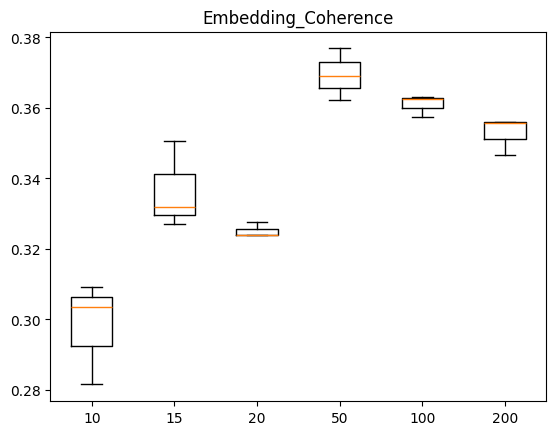

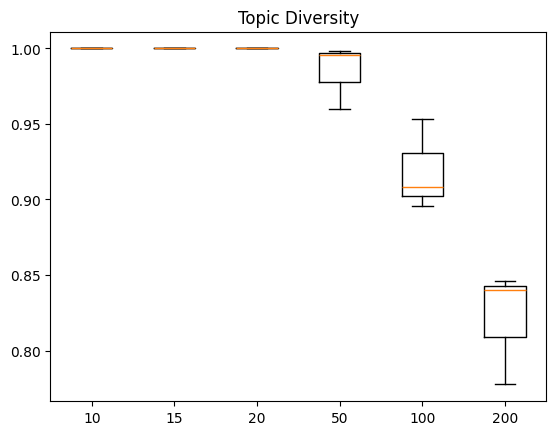

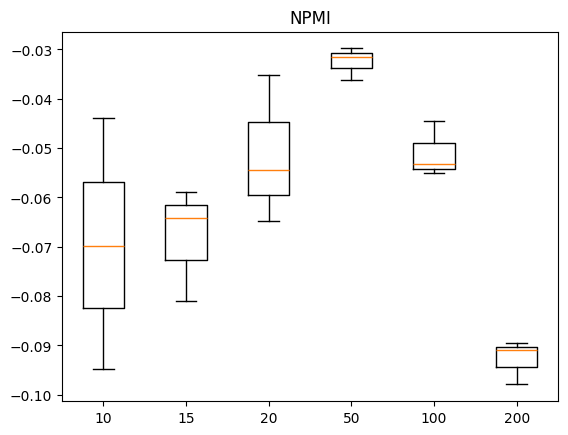

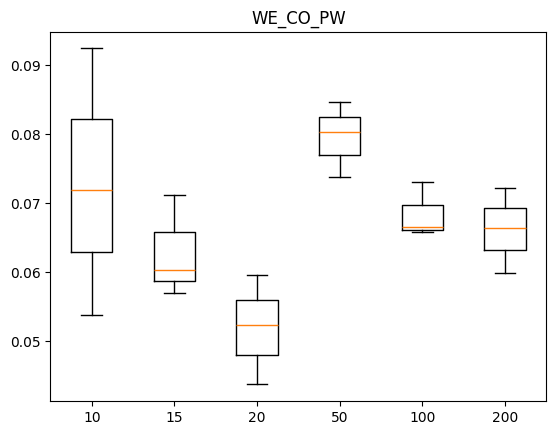

In [22]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Embedding_Coherence", "Topic Diversity", "NPMI", "WE_CO_PW"]

# make a boxplot for each metric and each number of topics

for metric in metrics:
    data = []
    for n in n_topics:
        data.append([res[metric] for res in results[n]])
    plt.boxplot(data)
    plt.title(metric)
    plt.xticks(np.arange(len(n_topics)) + 1, n_topics)
    plt.show()


# save results


Available metrics: ['NPMI', 'WE_CO_PW', 'Embedding_Coherence', 'Topic Diversity', 'WESS']
                            TNTM EVALUATION RESULTS                             
+------------+------------------+----------------------------+-----------------------+-------------------+-----------------------+
|   n_topics | NPMI Coherence   | Embedding Coherence (PW)   | Embedding Coherence   | Topic Diversity   | Embedding Diversity   |
+============+==================+============================+=======================+===================+=======================+
|         10 | -0.0695 ± 0.0208 | 0.0727 ± 0.0157            | 0.2982 ± 0.0120       | 1.0000 ± 0.0000   | 0.4308 ± 0.0289       |
+------------+------------------+----------------------------+-----------------------+-------------------+-----------------------+
|         15 | -0.0680 ± 0.0095 | 0.0629 ± 0.0061            | 0.3365 ± 0.0101       | 1.0000 ± 0.0000   | 0.3934 ± 0.0171       |
+------------+------------------+----------

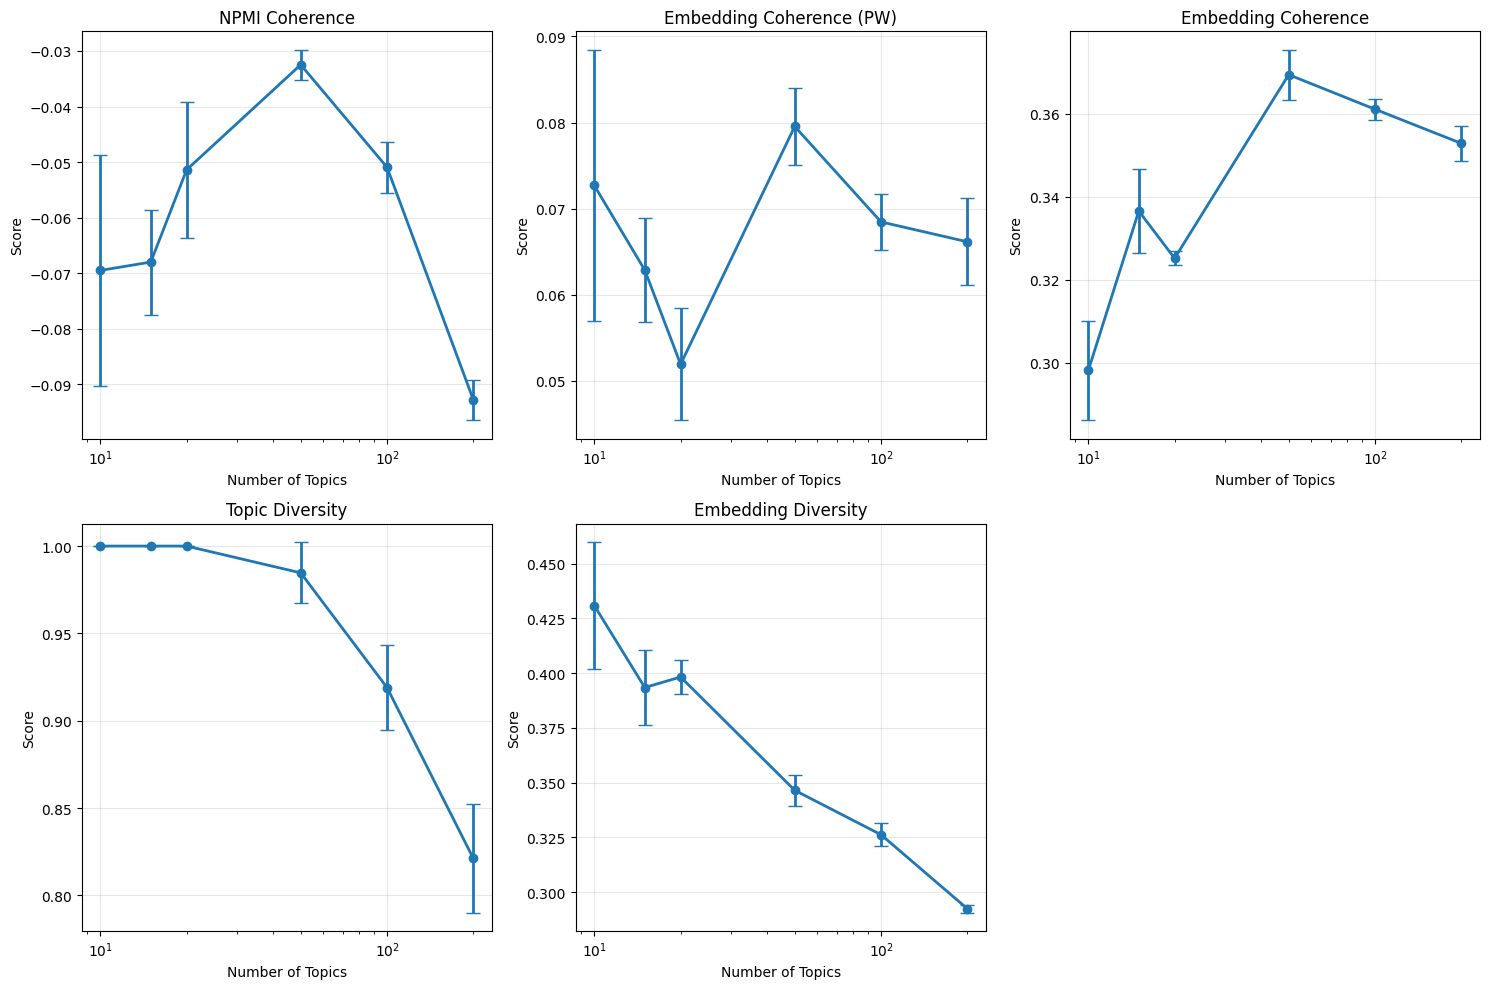

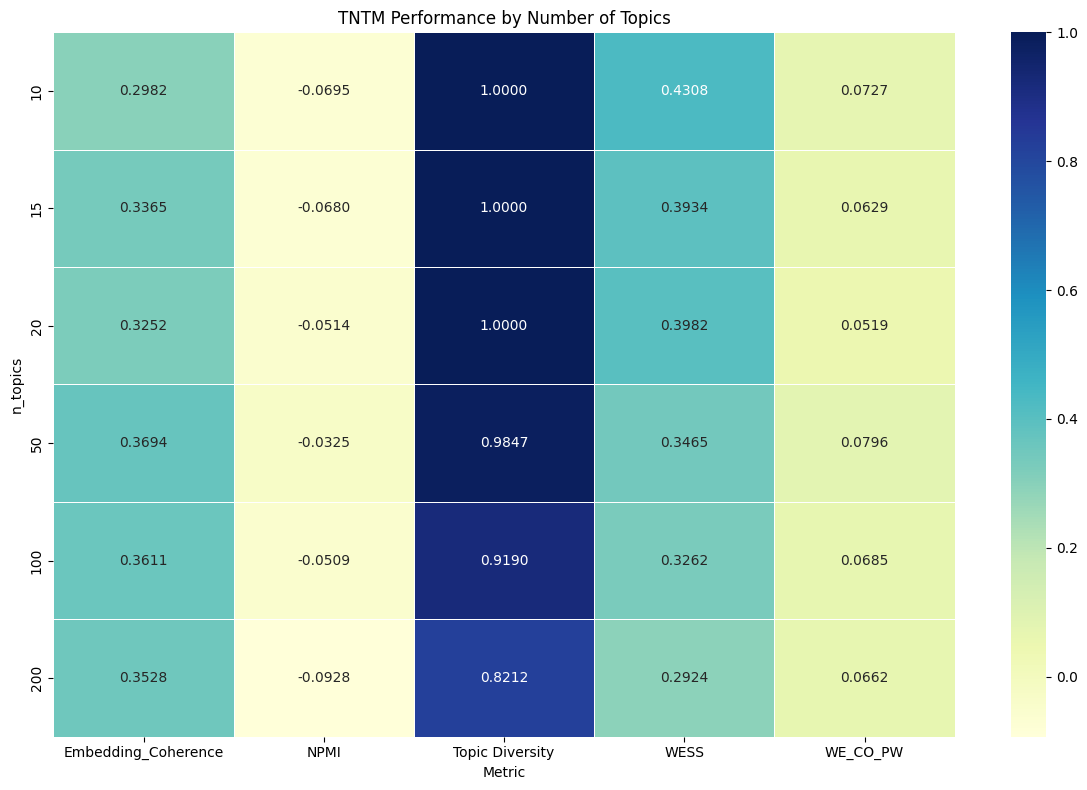

Best number of topics for each metric:
  - NPMI Coherence: 50 topics (score: -0.0325)
  - Embedding Coherence (PW): 50 topics (score: 0.0796)
  - Embedding Coherence: 50 topics (score: 0.3694)
  - Topic Diversity: 10 topics (score: 1.0000)
  - Embedding Diversity: 10 topics (score: 0.4308)

Results saved to ../msc/SavedResults/TNTM_n_topics_results.csv


In [23]:
# Print the final results in a nicely formatted table
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Define metrics to display - using only metrics that are available in the results
# First, check which metrics are available in the results
available_metrics = set()
for n_topic in n_topics:
    if n_topic in results and results[n_topic]:
        available_metrics.update(results[n_topic][0].keys())

# Define metrics to display (only use available metrics)
metrics = [
    m
    for m in ["NPMI", "WE_CO_PW", "Embedding_Coherence", "Topic Diversity", "WESS"]
    if m in available_metrics
]
print(f"Available metrics: {metrics}")

metric_display_names = {
    "NPMI": "NPMI Coherence",
    "WE_CO_PW": "Embedding Coherence (PW)",
    "Embedding_Coherence": "Embedding Coherence",
    "Topic Diversity": "Topic Diversity",
    "WESS": "Embedding Diversity",
}

# Create a DataFrame for the results
results_df = pd.DataFrame()

for n_topic in n_topics:
    # Calculate mean and std for each metric
    for metric in metrics:
        values = [res[metric] for res in results[n_topic]]
        mean_val = np.mean(values)
        std_val = np.std(values)

        # Add to DataFrame
        results_df = pd.concat(
            [
                results_df,
                pd.DataFrame(
                    {
                        "n_topics": [n_topic],
                        "Metric": [metric],
                        "Mean": [mean_val],
                        "Std": [std_val],
                    }
                ),
            ]
        )

# 1. Print a nicely formatted table
print("=" * 80)
print("TNTM EVALUATION RESULTS".center(80))
print("=" * 80)

# Group by n_topics and create a pretty table
table_data = []
headers = ["n_topics"] + [metric_display_names.get(m, m) for m in metrics]

for n_topic in sorted(n_topics):
    row = [n_topic]
    for metric in metrics:
        metric_data = results_df[
            (results_df["n_topics"] == n_topic) & (results_df["Metric"] == metric)
        ]
        if not metric_data.empty:
            mean_val = metric_data["Mean"].values[0]
            std_val = metric_data["Std"].values[0]
            row.append(f"{mean_val:.4f} ± {std_val:.4f}")
        else:
            row.append("N/A")
    table_data.append(row)

print(tabulate(table_data, headers=headers, tablefmt="grid"))
print("\n")

# 2. Create line plots for each metric
plt.figure(figsize=(15, 10))

for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i + 1)

    # Get data for this metric
    metric_data = results_df[results_df["Metric"] == metric]

    # Sort by n_topics
    metric_data = metric_data.sort_values("n_topics")

    # Plot mean with error bars
    plt.errorbar(
        metric_data["n_topics"],
        metric_data["Mean"],
        yerr=metric_data["Std"],
        marker="o",
        capsize=5,
        linewidth=2,
    )

    plt.title(metric_display_names.get(metric, metric))
    plt.xlabel("Number of Topics")
    plt.ylabel("Score")
    plt.grid(True, alpha=0.3)
    plt.xscale("log")  # Use log scale for x-axis due to wide range of topic numbers

# Create directory if it doesn't exist
import os

os.makedirs("../msc/SavedResults", exist_ok=True)

plt.tight_layout()
plt.savefig("../msc/SavedResults/TNTM_n_topics_results.png", dpi=300)
plt.show()

# 3. Create a heatmap of results
pivot_df = results_df.pivot_table(index="n_topics", columns="Metric", values="Mean")
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, fmt=".4f", cmap="YlGnBu", linewidths=0.5)
plt.title("TNTM Performance by Number of Topics")
plt.tight_layout()
plt.savefig("../msc/SavedResults/TNTM_n_topics_heatmap.png", dpi=300)
plt.show()

# 4. Find the best number of topics for each metric
print("Best number of topics for each metric:")
for metric in metrics:
    metric_data = results_df[results_df["Metric"] == metric]
    if not metric_data.empty:
        # Find the row with the maximum mean value
        best_row_idx = metric_data["Mean"].values.argmax()
        best_row = metric_data.iloc[best_row_idx]

        # Extract the values as Python primitives
        best_n_topics = int(best_row["n_topics"])
        best_mean = float(best_row["Mean"])

        print(
            f"  - {metric_display_names.get(metric, metric)}: {best_n_topics} topics (score: {best_mean:.4f})"
        )

# 5. Save results to CSV
results_df.to_csv("../msc/SavedResults/TNTM_n_topics_results.csv", index=False)
print("\nResults saved to ../msc/SavedResults/TNTM_n_topics_results.csv")
